# Module 10 - Milestone: Your First LLM Notebook

Use this notebook after Module 09B pretraining setup and Module 10 trainer tests are passing. The focus is the first real run: prepare a corpus, train a tiny TransformerLM, track validation loss, sample from the result, and run one controlled follow-up experiment.


In [8]:
from __future__ import annotations

from collections.abc import Callable
import contextlib
import hashlib
import io
import math
import pickle
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

import g2c
from g2c.tokenizer import BPETokenizer
from g2c.pretraining import Trainer, get_lm_batch, split_token_stream
from g2c.transformer import TransformerLM

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]
print("MPS available:", torch.backends.mps.is_available())


def format_training_progress(metrics: dict, *, max_steps: int, tokens_per_step: int) -> Markdown:
    step = int(metrics["step"])
    elapsed_s = float(metrics.get("elapsed_s") or 0.0)
    tokens_s = ((step + 1) * tokens_per_step / elapsed_s) if elapsed_s else 0.0
    val_loss = metrics.get("val_loss")
    val_text = ""
    if val_loss is not None:
        val_text = f" | val loss `{val_loss:.3f}` | val ppl `{math.exp(val_loss):.1f}`"
    return Markdown(
        f"`step {step + 1:,}/{max_steps:,}` | "
        f"train loss `{metrics['train_loss']:.3f}`"
        f"{val_text} | "
        f"lr `{metrics['lr']:.2e}` | "
        f"grad norm `{metrics['grad_norm']:.2f}` | "
        f"elapsed `{elapsed_s / 60:.1f} min` | "
        f"tokens/s `{tokens_s:,.0f}`"
    )


MPS available: True


## Run Configuration

Change these values before running the training cells. `target_vocab_size` is the requested BPE vocabulary size; the tokenizer section will report the actual `vocab_size` used by the model.

In [33]:
trainer_device = "auto"
text_max_chars = 1_000_000
target_vocab_size = 1024

model_config = {
    "embedding_dim": 128,
    "num_layers": 4,
    "num_heads": 4,
    "max_seq_len": 128,
    "hidden_dim": 512,
}

trainer_config = {
    "batch_size": 32,
    "context_length": 64,
    "max_steps": 2000,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 100,
    "weight_decay": 0.01,
    "grad_clip": 1.0,
    "eval_every": 100,
    "eval_iters": 10,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
trainer_seed = 0

raw_sample_config = {
    "prompt": "KING:",
    "max_new_tokens": 300,
    "temperature": 0.8,
    "top_k": None,
    "printable_only": False,
    "seed": 1,
}

readable_sample_config = {
    "prompt": "KING:",
    "max_new_tokens": 300,
    "temperature": 0.5,
    "top_k": 20,
    "printable_only": True,
    "seed": 1,
}
tinystories_raw_sample_config = {
    "prompt": "Once upon a time,",
    "max_new_tokens": 300,
    "temperature": 0.8,
    "top_k": None,
    "printable_only": False,
    "seed": 1,
}

tinystories_readable_sample_config = {
    "prompt": "Once upon a time,",
    "max_new_tokens": 300,
    "temperature": 0.5,
    "top_k": 20,
    "printable_only": True,
    "seed": 1,
}

short_run_model_config = {
    "embedding_dim": 64,
    "num_layers": 2,
    "num_heads": 4,
    "max_seq_len": 64,
    "hidden_dim": 128,
}

lr_sweep_lrs = [1e-4, 3e-4, 1e-3, 3e-3]
lr_sweep_steps = 150
lr_sweep_trainer_config = {
    "batch_size": 16,
    "context_length": 48,
    "weight_decay": 0.01,
    "grad_clip": 1.0,
    "eval_iters": 5,
    "device": trainer_device,
    "optimizer": "adamw",
}

ablation_steps = 150
ablation_max_lr = 3e-4
ablation_min_lr = 3e-5
ablation_log_every = 10
ablation_trainer_config = {
    "batch_size": 16,
    "context_length": 48,
    "weight_decay": 0.01,
    "eval_iters": 5,
    "device": trainer_device,
    "optimizer": "adamw",
}
ablation_cases = [
    {"name": "warmup + clip", "warmup_steps": 15, "grad_clip": 1.0},
    {"name": "no warmup", "warmup_steps": 0, "grad_clip": 1.0},
    {"name": "no clipping", "warmup_steps": 15, "grad_clip": None},
]

run_tinystories_5m = True
run_tinystories_30m = True
tinystories_train_max_chars = 5_000_000
tinystories_valid_max_chars = 200_000
# Use byte-level tokenization for the large-corpus scale-up so corpus prep is fast.
# Raising this trains BPE on TinyStories, which is much slower with the Module 04 tokenizer.
tinystories_target_vocab_size = 2048

tinystories_5m_model_config = {
    "embedding_dim": 256,
    "num_layers": 6,
    "num_heads": 8,
    "max_seq_len": 256,
    "hidden_dim": 1024,
}
tinystories_5m_trainer_config = {
    "batch_size": 16,
    "context_length": 256,
    "max_steps": 3000,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 200,
    "weight_decay": 0.05,
    "grad_clip": 1.0,
    "eval_every": 100,
    "eval_iters": 10,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}

tinystories_30m_model_config = {
    "embedding_dim": 512,
    "num_layers": 9,
    "num_heads": 8,
    "max_seq_len": 256,
    "hidden_dim": 2048,
}
tinystories_30m_trainer_config = {
    "batch_size": 8,
    "context_length": 256,
    "max_steps": 5000,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 200,
    "weight_decay": 0.05,
    "grad_clip": 1.0,
    "eval_every": 100,
    "eval_iters": 5,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}


## Before the Notebook

Module 03B should already provide `AdamW`, `cosine_with_warmup`, and `clip_grad_norm_`. Module 09B should already provide `get_lm_batch` and `lm_cross_entropy`. For Module 10, implement `Trainer.train_step`. The trainer also depends on your completed `TransformerLM` from Module 09.


In [10]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_training.py -x"
"Then run: .venv/bin/python -m pytest tests/test_pretraining_setup.py -x"
"Then run: .venv/bin/python -m pytest tests/test_pretraining.py -x"
"Question: Which trainer test is the next one failing, and which part of train_step does it point at?"
"Answer: "


'Answer: '

In [11]:
for test_file in ["tests/test_training.py", "tests/test_pretraining_setup.py", "tests/test_pretraining.py"]:
    result = subprocess.run(
        [sys.executable, "-m", "pytest", test_file],
        cwd=repo_root,
        text=True,
        capture_output=True,
    )
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    assert result.returncode == 0, f"{test_file} is not passing yet."

print("Module 03B, Module 09B, and Module 10 tests passed.")


.....................                                                    [100%]
21 passed in 0.52s

..............                                                           [100%]
14 passed in 0.51s

........................                                                 [100%]
24 passed in 1.49s

Module 03B, Module 09B, and Module 10 tests passed.


## Exercise 1 - Prepare TinyShakespeare or Fallback Text

Use the downloaded TinyShakespeare file if setup has it. The fallback keeps the notebook runnable, but TinyShakespeare is the intended starter corpus. Keep this first run small: it proves the trainer works before you spend time on TinyStories.

In [12]:
def read_text_prefix(path: Path, max_chars: int) -> str:
    with path.open("r", encoding="utf-8") as f:
        return f.read(max_chars)


def load_pretraining_text(max_chars: int = 200_000) -> str:
    path = repo_root / "data" / "tinyshakespeare.txt"
    if path.exists():
        return read_text_prefix(path, max_chars)

    base = """
    FIRST STUDENT:
    the model predicts the next token from the context.
    SECOND STUDENT:
    the context helps the model choose a better next token.
    FIRST STUDENT:
    gradients update embeddings and transformer blocks.
    """
    return ("\n".join(line.strip() for line in base.strip().splitlines()) + "\n") * 1000


def tokenizer_progress_every(vocab_size: int) -> int:
    return max(1, (vocab_size - 256) // 50)


def make_tokenizer_progress(label: str) -> Callable[[dict[str, int]], None]:
    start = time.perf_counter()
    progress = display(Markdown(f"{label} tokenizer training starting..."), display_id=True)

    def on_progress(metrics: dict[str, int]) -> None:
        elapsed = time.perf_counter() - start
        progress.update(
            Markdown(
                f"{label} tokenizer vocab `{metrics['vocab_size']:,}/{metrics['target_vocab_size']:,}` "
                f"| merges `{metrics['num_merges']:,}` "
                f"| tokens `{metrics['token_count']:,}` "
                f"| last merge count `{metrics['last_pair_count']:,}` "
                f"| elapsed `{elapsed:.1f}s`"
            )
        )

    return on_progress


def tokenized_corpus_cache_path(label: str, text: str, vocab_size: int) -> Path:
    digest = hashlib.sha256(text.encode("utf-8")).hexdigest()[:16]
    safe_label = label.replace("/", "-")
    return repo_root / "data" / "tokenizer-cache" / f"{safe_label}-v{vocab_size}-{len(text)}-{digest}.pkl"


def load_or_train_tokenized_corpus(text: str, vocab_size: int, *, label: str = "corpus") -> tuple[BPETokenizer, list[int]]:
    cache_path = tokenized_corpus_cache_path(label, text, vocab_size)
    if cache_path.exists():
        start = time.perf_counter()
        with cache_path.open("rb") as f:
            state = pickle.load(f)
        tokenizer = BPETokenizer()
        tokenizer.merges = state["merges"]
        tokenizer.vocab = state["vocab"]
        ids = state["ids"]
        print(f"loaded tokenizer cache in {time.perf_counter() - start:.2f}s: {cache_path.relative_to(repo_root)}")
        return tokenizer, ids

    start = time.perf_counter()
    tokenizer = BPETokenizer()
    if vocab_size == 256:
        ids = list(text.encode("utf-8"))
    else:
        with contextlib.redirect_stdout(io.StringIO()):
            ids = tokenizer.train(
                text,
                vocab_size=vocab_size,
                on_progress=make_tokenizer_progress(label),
                progress_every=tokenizer_progress_every(vocab_size),
            )

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    with cache_path.open("wb") as f:
        pickle.dump({"merges": tokenizer.merges, "vocab": tokenizer.vocab, "ids": ids}, f)
    print(f"trained tokenizer and saved cache in {time.perf_counter() - start:.2f}s: {cache_path.relative_to(repo_root)}")
    return tokenizer, ids


def tokenized_pair_cache_path(label: str, train_text: str, val_text: str, vocab_size: int) -> Path:
    digest = hashlib.sha256((train_text + "\0" + val_text).encode("utf-8")).hexdigest()[:16]
    safe_label = label.replace("/", "-")
    total_chars = len(train_text) + len(val_text)
    return repo_root / "data" / "tokenizer-cache" / f"{safe_label}-pair-v{vocab_size}-{total_chars}-{digest}.pkl"


def load_or_train_tokenized_pair(
    train_text: str,
    val_text: str,
    vocab_size: int,
    *,
    label: str,
) -> tuple[BPETokenizer, torch.Tensor, torch.Tensor]:
    cache_path = tokenized_pair_cache_path(label, train_text, val_text, vocab_size)
    if cache_path.exists():
        start = time.perf_counter()
        with cache_path.open("rb") as f:
            state = pickle.load(f)
        tokenizer = BPETokenizer()
        tokenizer.merges = state["merges"]
        tokenizer.vocab = state["vocab"]
        train_ids = torch.tensor(state["train_ids"], dtype=torch.long)
        val_ids = torch.tensor(state["val_ids"], dtype=torch.long)
        print(f"loaded tokenizer cache in {time.perf_counter() - start:.2f}s: {cache_path.relative_to(repo_root)}")
        return tokenizer, train_ids, val_ids

    start = time.perf_counter()
    tokenizer = BPETokenizer()
    if vocab_size == 256:
        train_encoded = list(train_text.encode("utf-8"))
        val_encoded = list(val_text.encode("utf-8"))
    else:
        with contextlib.redirect_stdout(io.StringIO()):
            train_encoded = tokenizer.train(
                train_text,
                vocab_size=vocab_size,
                on_progress=make_tokenizer_progress(label),
                progress_every=tokenizer_progress_every(vocab_size),
            )
        encode_status = display(Markdown(f"{label} tokenizer encoding validation text..."), display_id=True)
        val_encoded = tokenizer.encode(val_text)
        encode_status.update(Markdown(f"{label} tokenizer validation encoded: `{len(val_encoded):,}` tokens"))

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_status = display(Markdown(f"{label} tokenizer writing cache..."), display_id=True)
    with cache_path.open("wb") as f:
        pickle.dump(
            {
                "merges": tokenizer.merges,
                "vocab": tokenizer.vocab,
                "train_ids": train_encoded,
                "val_ids": val_encoded,
            },
            f,
        )
    cache_status.update(Markdown(f"{label} tokenizer cache saved."))
    print(f"trained tokenizer and saved cache in {time.perf_counter() - start:.2f}s: {cache_path.relative_to(repo_root)}")
    return (
        tokenizer,
        torch.tensor(train_encoded, dtype=torch.long),
        torch.tensor(val_encoded, dtype=torch.long),
    )


text = load_pretraining_text(max_chars=text_max_chars)
tokenizer, encoded_ids = load_or_train_tokenized_corpus(text, target_vocab_size, label="tinyshakespeare")
all_ids = torch.tensor(encoded_ids, dtype=torch.long)
vocab_size = len(tokenizer.vocab)
train_ids, val_ids = split_token_stream(all_ids, train_fraction=0.9)

print("characters:", len(text))
print("tokens:", len(all_ids))
print("vocab size:", vocab_size)
print("uniform-loss baseline:", math.log(vocab_size))
print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))
assert len(val_ids) > 128

loaded tokenizer cache in 0.00s: data/tokenizer-cache/tinyshakespeare-v1024-1000000-7684416efa50ba71.pkl
characters: 1000000
tokens: 396408
vocab size: 1024
uniform-loss baseline: 6.931471805599453
train tokens: 356767
val tokens: 39641


In [13]:
"Question: Why can a larger BPE vocabulary reduce token count but make the output logits tensor wider?"
"Answer: "
"Question: Why should validation text come from held-out token positions rather than the same windows used for training?"
"Answer: "

'Answer: '

## Exercise 2 - Train a Tiny TransformerLM

This is the first real pretraining loop now that Module 09B owns the batch and loss setup. The default below is a small payoff run rather than a smoke test: it should take longer, but the sample should move past pure token soup. If you only want to verify wiring, reduce `max_steps`, `embedding_dim`, and `num_layers` temporarily.

In [14]:
torch.manual_seed(0)
model = TransformerLM(vocab_size=vocab_size, **model_config)

trainer = Trainer(
    model,
    **trainer_config,
    generator=torch.Generator().manual_seed(trainer_seed),
)

print("training device:", trainer.device)
progress = display(Markdown("Training starting..."), display_id=True)


def log_training_progress(metrics: dict) -> None:
    progress.update(
        format_training_progress(
            metrics,
            max_steps=trainer.max_steps,
            tokens_per_step=trainer.batch_size * trainer.context_length,
        )
    )


history = trainer.train(train_ids, val_ids, on_log=log_training_progress)
print("final train loss:", history["train_loss"][-1])
print("final val loss:", history["val_loss"][-1])
print("final val perplexity:", math.exp(history["val_loss"][-1]))

training device: mps


`step 2,000/2,000` | train loss `4.054` | val loss `4.369` | val ppl `79.0` | lr `3.00e-05` | grad norm `1.42` | elapsed `1.4 min` | tokens/s `47,609`

final train loss: 4.0543622970581055
final val loss: 4.369071388244629
final val perplexity: 78.97026492387835


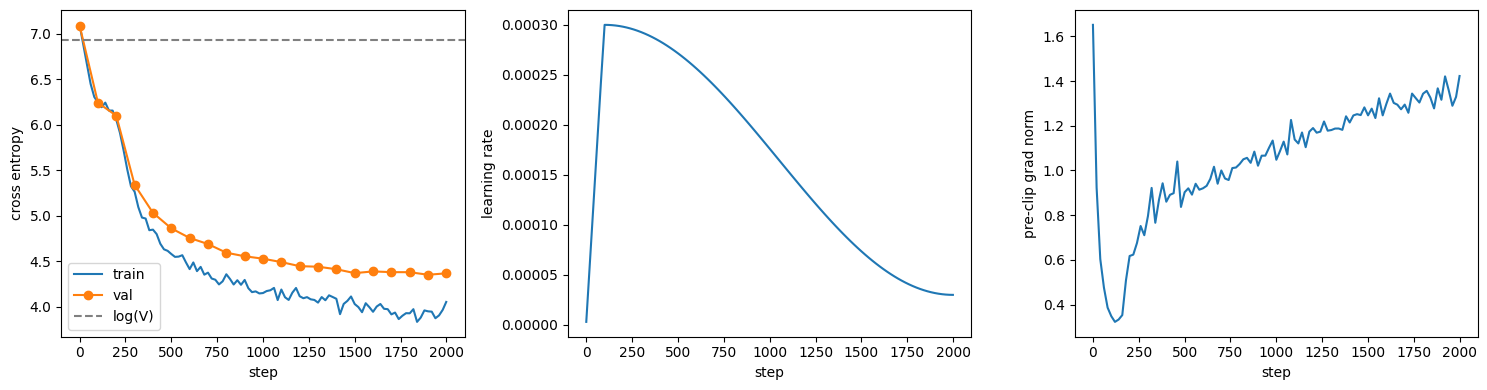

In [15]:
def plot_training_history(history: dict[str, list], *, baseline_loss: float | None = None) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history["step"], history["train_loss"], label="train")
    if history["val_loss"]:
        axes[0].plot(history["val_step"], history["val_loss"], marker="o", label="val")
    if baseline_loss is not None:
        axes[0].axhline(baseline_loss, color="gray", linestyle="--", label="log(V)")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("cross entropy")
    axes[0].legend()

    axes[1].plot(history["step"], history["lr"])
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("learning rate")

    axes[2].plot(history["step"], history["grad_norm"])
    axes[2].set_xlabel("step")
    axes[2].set_ylabel("pre-clip grad norm")

    fig.tight_layout()
    plt.show()


plot_training_history(history, baseline_loss=math.log(vocab_size))

In [16]:
checkpoint_path = repo_root / "data" / "module10-first-llm.pt"
checkpoint_path.parent.mkdir(exist_ok=True)
torch.save(
    {
        "vocab_size": vocab_size,
        "target_vocab_size": target_vocab_size,
        "model_config": {
            "embedding_dim": model.embedding_dim,
            "num_layers": model.num_layers,
            "num_heads": model.num_heads,
            "max_seq_len": model.max_seq_len,
            "hidden_dim": model.blocks[0].ffn.hidden_dim if model.blocks else None,
        },
        "params": [p.detach().cpu() for p in model.parameters()],
        "history": history,
    },
    checkpoint_path,
)
print("saved checkpoint:", checkpoint_path)


saved checkpoint: /Users/colkitt/sith/toys/courses/g2c/data/module10-first-llm.pt


In [17]:
"Question: Does validation loss track training loss, or is one moving much faster?"
"Answer: "
"Question: Are gradient norms largest early in training? What does clipping seem to be doing?"
"Answer: "

'Answer: '

## Exercise 3 - Sample During or After Training

Module 11 will build the real generation utilities. For now, use a minimal local sampler so you can qualitatively inspect what pretraining learned.

Byte-level BPE can sample raw byte tokens before the model is well trained. The raw escaped sample shows that behavior directly; the readable sample uses top-k sampling and blocks control/invalid-byte tokens so the output is easier to inspect.

In [18]:
def token_is_readable(tokenizer: BPETokenizer, token_id: int) -> bool:
    piece = tokenizer.decode([token_id])
    if not piece or "�" in piece:
        return False
    return all(ch in "\n\t" or ch.isprintable() for ch in piece)


def readable_token_mask(tokenizer: BPETokenizer) -> torch.Tensor:
    return torch.tensor(
        [token_is_readable(tokenizer, token_id) for token_id in range(len(tokenizer.vocab))],
        dtype=torch.bool,
    )


def apply_top_k(logits: torch.Tensor, top_k: int | None) -> torch.Tensor:
    if top_k is None:
        return logits
    k = min(top_k, logits.numel())
    cutoff = torch.topk(logits, k).values[-1]
    return logits.masked_fill(logits < cutoff, float("-inf"))


@torch.no_grad()
def sample_text(
    model: TransformerLM,
    tokenizer: BPETokenizer,
    prompt: str,
    *,
    max_new_tokens: int = 200,
    temperature: float = 0.5,
    top_k: int | None = 20,
    printable_only: bool = True,
    seed: int = 0,
) -> str:
    device = next(iter(model.parameters())).device
    ids = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)
    generator = torch.Generator().manual_seed(seed)
    printable_mask = readable_token_mask(tokenizer) if printable_only else None

    for _ in range(max_new_tokens):
        ctx = ids[-model.max_seq_len :].unsqueeze(0)
        logits = model(ctx)[0, -1].clone()

        if printable_mask is not None:
            mask = printable_mask.to(device=logits.device)
            logits = logits.masked_fill(~mask, float("-inf"))

        if temperature == 0.0:
            next_id = logits.argmax().reshape(1)
        else:
            logits = apply_top_k(logits / temperature, top_k)
            probs = torch.softmax(logits, dim=-1).detach().cpu()
            next_id = torch.multinomial(probs, 1, generator=generator).to(device)
        ids = torch.cat([ids, next_id.to(device=ids.device)])

    return tokenizer.decode(ids.detach().cpu().tolist())


def escaped_text(text: str) -> str:
    return text.encode("unicode_escape", errors="backslashreplace").decode("ascii")


def show_sample_outputs(
    name: str,
    model: TransformerLM,
    tokenizer: BPETokenizer,
    raw_config: dict,
    readable_config: dict,
) -> None:
    raw_sample = sample_text(model, tokenizer, **raw_config)
    readable_sample = sample_text(model, tokenizer, **readable_config)

    print(f"{name} raw sample, escaped so control bytes do not wreck the notebook output")
    print("-" * 72)
    print(escaped_text(raw_sample))
    print(f"\n{name} readable top-k sample")
    print("-" * 72)
    print(readable_sample)


show_sample_outputs("TinyShakespeare", model, tokenizer, raw_sample_config, readable_sample_config)

TinyShakespeare raw sample, escaped so control bytes do not wreck the notebook output
------------------------------------------------------------------------
KING: why show as tearn resd,\nThat dit of no such with parrich\nFrance's taint merrunesters will sign, that tongues and unto my lords\nWhich myself hageful honours for warcihaves his Lord their peed\nThat warfterloa heavest, though through the th prend the pects\nA cons, cour more thkclocks!tyrilgkown fear, a k, that tre he chm,\npt can metfremm, cour ded, from the serst tchcter pttter,\nO ladear to btide her honours are fdlt and st, weven perceple,\nOnult thee w-blu sa swage w-tle,\nAnd own to st; we'll steek! didst, the smm fould\nOf all with skst and to th'd wartffffft should be bout us is bt to see me of my bourth our of stridt blam.\nI shavy commddmurt forepast, that 

TinyShakespeare readable top-k sample
------------------------------------------------------------------------
KING: why wack a blucking the king,
Against me

In [19]:
"Question: How different is the raw escaped sample from the readable filtered sample?"
"Answer: "

"Question: What improved first: punctuation and line shape, local words, or global meaning?"
"Answer: "

"Question: If the readable sample is still incoherent, is that more likely a sampling issue or a training-budget/model-size issue?"
"Answer: "

'Answer: '

## Exercise 4 - TinyStories Scale-Up

TinyShakespeare proves the loop works, but it is too small for larger models. If you have downloaded TinyStories with `./datasets.sh tinystories`, run the ~5M-parameter experiment first, inspect the curves, and compare raw/readable samples. After that curve looks healthy, flip `run_tinystories_30m = True` in the config cell and repeat the same train/curves/samples loop for the ~30M-parameter experiment. If TinyStories is missing, these cells skip cleanly.

In [20]:
def load_tinystories_text(
    *,
    train_max_chars: int,
    valid_max_chars: int,
) -> tuple[str, str] | None:
    train_path = repo_root / "data" / "tinystories" / "TinyStories-train.txt"
    valid_path = repo_root / "data" / "tinystories" / "TinyStories-valid.txt"
    if not train_path.exists() or not valid_path.exists():
        print("Skipping TinyStories scale-up. Run: ./datasets.sh tinystories")
        return None
    return (
        read_text_prefix(train_path, train_max_chars),
        read_text_prefix(valid_path, valid_max_chars),
    )


def count_parameters(model: TransformerLM) -> int:
    return sum(p.numel() for p in model.parameters())


def train_scaleup_run(
    name: str,
    *,
    tokenizer: BPETokenizer,
    train_ids: torch.Tensor,
    val_ids: torch.Tensor,
    model_config: dict,
    trainer_config: dict,
    seed: int,
) -> tuple[TransformerLM, dict[str, list]]:
    torch.manual_seed(seed)
    scale_model = TransformerLM(vocab_size=len(tokenizer.vocab), **model_config)
    scale_trainer = Trainer(
        scale_model,
        **trainer_config,
        generator=torch.Generator().manual_seed(seed),
    )
    print(f"{name} params: {count_parameters(scale_model):,}")
    print("training device:", scale_trainer.device)
    progress = display(Markdown(f"{name} training starting..."), display_id=True)

    def log_progress(metrics: dict) -> None:
        progress.update(
            format_training_progress(
                metrics,
                max_steps=scale_trainer.max_steps,
                tokens_per_step=scale_trainer.batch_size * scale_trainer.context_length,
            )
        )

    scale_history = scale_trainer.train(train_ids, val_ids, on_log=log_progress)
    print("final train loss:", scale_history["train_loss"][-1])
    print("final val loss:", scale_history["val_loss"][-1])
    print("final val perplexity:", math.exp(scale_history["val_loss"][-1]))
    return scale_model, scale_history


### TinyStories Tokenizer Prep

Run this once before the TinyStories 5M or 30M training cells. It loads the corpus slice, trains or loads the tokenizer cache, encodes train/validation IDs, and leaves the tensors in memory for both model sizes.

In [21]:
tinystories_text = load_tinystories_text(
    train_max_chars=tinystories_train_max_chars,
    valid_max_chars=tinystories_valid_max_chars,
)
tinystories_ready = tinystories_text is not None

if tinystories_ready:
    tinystories_train_text, tinystories_valid_text = tinystories_text
    tinystories_tokenizer, tinystories_train_ids, tinystories_val_ids = load_or_train_tokenized_pair(
        tinystories_train_text,
        tinystories_valid_text,
        tinystories_target_vocab_size,
        label="tinystories",
    )
    print("TinyStories train characters:", len(tinystories_train_text))
    print("TinyStories valid characters:", len(tinystories_valid_text))
    print("TinyStories train tokens:", len(tinystories_train_ids))
    print("TinyStories valid tokens:", len(tinystories_val_ids))
    print("TinyStories vocab size:", len(tinystories_tokenizer.vocab))
else:
    tinystories_tokenizer = None
    tinystories_train_ids = None
    tinystories_val_ids = None


loaded tokenizer cache in 0.05s: data/tokenizer-cache/tinystories-pair-v2048-5200000-53da692897671bb1.pkl
TinyStories train characters: 5000000
TinyStories valid characters: 200000
TinyStories train tokens: 1159691
TinyStories valid tokens: 44973
TinyStories vocab size: 2048


### TinyStories 5M Training

This cell uses the already-prepared TinyStories token IDs. Re-running it restarts the 5M model training without retraining or re-encoding the tokenizer.

In [22]:
tinystories_5m_model = None
tinystories_5m_history = None

if tinystories_ready and run_tinystories_5m:
    assert tinystories_tokenizer is not None
    assert tinystories_train_ids is not None
    assert tinystories_val_ids is not None
    tinystories_5m_model, tinystories_5m_history = train_scaleup_run(
        "TinyStories 5M",
        tokenizer=tinystories_tokenizer,
        train_ids=tinystories_train_ids,
        val_ids=tinystories_val_ids,
        model_config=tinystories_5m_model_config,
        trainer_config=tinystories_5m_trainer_config,
        seed=1,
    )
elif tinystories_ready:
    print("TinyStories 5M run disabled. Set run_tinystories_5m = True in the config cell.")


TinyStories 5M params: 5,855,232
training device: mps


`step 3,000/3,000` | train loss `3.271` | val loss `3.517` | val ppl `33.7` | lr `3.00e-05` | grad norm `1.60` | elapsed `19.8 min` | tokens/s `10,335`

final train loss: 3.27078914642334
final val loss: 3.5172693490982057
final val perplexity: 33.6923008252533


### TinyStories 5M Curves and Samples

Run these immediately after the 5M training cell. The curve tells you whether training is healthy; the samples tell you what that loss feels like as text.

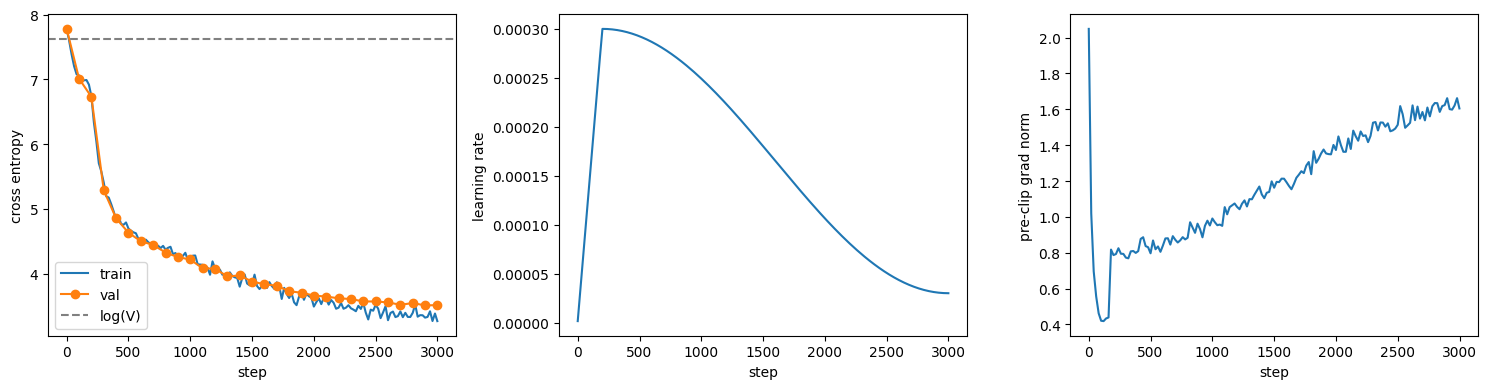

In [23]:
if tinystories_5m_history is not None:
    assert tinystories_tokenizer is not None
    plot_training_history(tinystories_5m_history, baseline_loss=math.log(len(tinystories_tokenizer.vocab)))
elif tinystories_ready:
    print("Run the TinyStories 5M training cell before plotting curves.")


In [24]:
if tinystories_5m_model is not None:
    assert tinystories_tokenizer is not None
    show_sample_outputs(
        "TinyStories 5M",
        tinystories_5m_model,
        tinystories_tokenizer,
        tinystories_raw_sample_config,
        tinystories_readable_sample_config,
    )
elif tinystories_ready:
    print("Run the TinyStories 5M training cell before sampling.")


TinyStories 5M raw sample, escaped so control bytes do not wreck the notebook output
------------------------------------------------------------------------
Once upon a time,he nodded from behind the smooth. It was smooth. On was bushe'd was ready to go.\nSara and Ben were very happy again. They both enjoyed together. Jill had learned expanized by the light and able to flying new things to learn more big and sweetalmumbed and promised to be more careful to put them from the peactceping when they still colourful of different games.\n\u201cIt was doney! What a nice friend share this interesting game for wallings!\u201d\nSam said to Now he could always make him for dinner. With a little patient, Carle smiled as Lucy was hand wipe as she was too old and she knew she had setted.\n<|endoftext|>\n\nOnce upon a time there was a boy called Jack. He thought all day he liked to explore. Every day he would would run around him. One day, he found a pool on the floor, and he decided to go outside a

### TinyStories 30M Training

Enable `run_tinystories_30m` in the config cell before running this. It reuses the same TinyStories tokenizer and token IDs from the prep cell.

In [34]:
tinystories_30m_model = None
tinystories_30m_history = None

if tinystories_ready and run_tinystories_30m:
    assert tinystories_tokenizer is not None
    assert tinystories_train_ids is not None
    assert tinystories_val_ids is not None
    tinystories_30m_model, tinystories_30m_history = train_scaleup_run(
        "TinyStories 30M",
        tokenizer=tinystories_tokenizer,
        train_ids=tinystories_train_ids,
        val_ids=tinystories_val_ids,
        model_config=tinystories_30m_model_config,
        trainer_config=tinystories_30m_trainer_config,
        seed=2,
    )
elif tinystories_ready:
    print("TinyStories 30M run disabled. Set run_tinystories_30m = True in the config cell after the 5M run looks healthy.")


TinyStories 30M params: 30,602,752
training device: mps


`step 5,000/5,000` | train loss `2.168` | val loss `2.974` | val ppl `19.6` | lr `3.00e-05` | grad norm `2.24` | elapsed `54.6 min` | tokens/s `3,128`

final train loss: 2.1678948402404785
final val loss: 2.974448490142822
final val perplexity: 19.57882235794831


### TinyStories 30M Curves and Samples

Only run this after enabling `run_tinystories_30m`. It uses the same tokenizer, prompt, curve plot, and raw/readable sample comparison as the 5M run, so the qualitative difference is easier to judge.

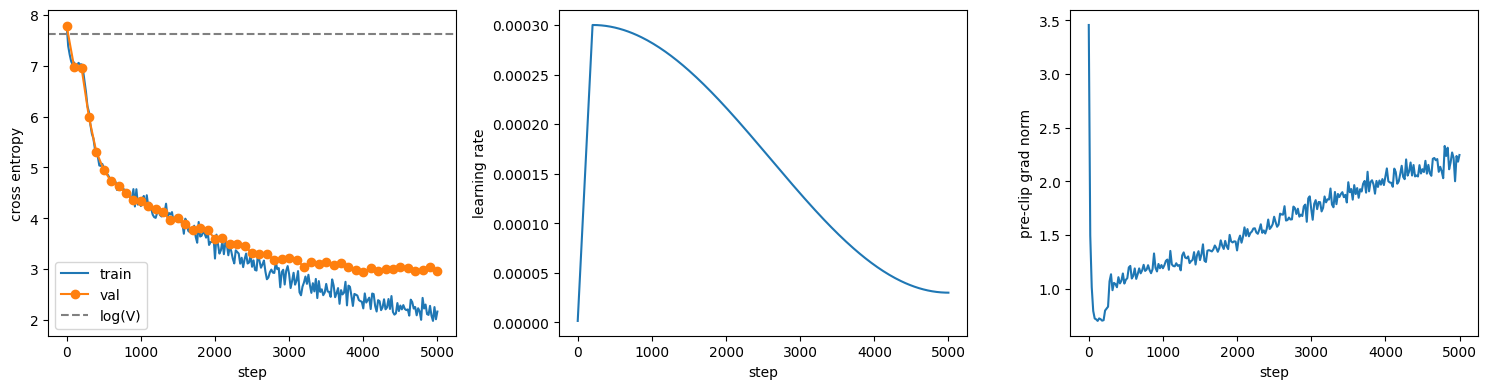

In [38]:
if tinystories_30m_history is not None:
    assert tinystories_tokenizer is not None
    plot_training_history(tinystories_30m_history, baseline_loss=math.log(len(tinystories_tokenizer.vocab)))
elif tinystories_ready:
    print("Run the TinyStories 30M training cell before plotting curves.")


In [39]:
if tinystories_30m_model is not None:
    assert tinystories_tokenizer is not None
    show_sample_outputs(
        "TinyStories 30M",
        tinystories_30m_model,
        tinystories_tokenizer,
        tinystories_raw_sample_config,
        tinystories_readable_sample_config,
    )
elif tinystories_ready:
    print("Run the TinyStories 30M training cell before sampling.")


TinyStories 30M raw sample, escaped so control bytes do not wreck the notebook output
------------------------------------------------------------------------
Once upon a time,\u201d he said.\nSo, Sometimes Spot, Lily returned some help. They went to the park to play with the leaves, and they did their friends.\nThey played some more. They had so much fun, but they did not know how to respect the man again. \nThe man was sad. He said, "If you make you feel my happy friend anymore. Do you want to play with me?" He said, "Let's share some new friends, like some food." Spot Now, Ben and they played a game. They had lots of fun swinging together, and share their toys. They shared many stories and castles.\nAt the end of the day, Spot became good friends.\n<|endoftext|>\nOne day, a little girl named Lily went for a walk in the woods. She thought it looked better but exciting to play with. She went fast where she looked. She saw a bird flying closer and saw that it was flying in the sky. It 

In [40]:
"Question: How does the TinyStories 5M validation curve compare with the TinyShakespeare curve?"
"Answer: "

"Question: If you ran the 30M model, did validation keep improving longer or overfit sooner?"
"Answer: "

"Question: What changed more visibly in samples: spelling, sentence shape, or story coherence?"
"Answer: "

'Answer: '

## Exercise 5 - Learning-Rate Sweep

This sweep uses fewer steps than the module's full exercise so it is practical inside a notebook. After the shape of the result makes sense, scale the step count up.

max_lr=0.0001 val_loss=6.719 perplexity=827.8
max_lr=0.0003 val_loss=6.374 perplexity=586.5
max_lr=0.001 val_loss=6.218 perplexity=501.9
max_lr=0.003 val_loss=6.205 perplexity=495.3


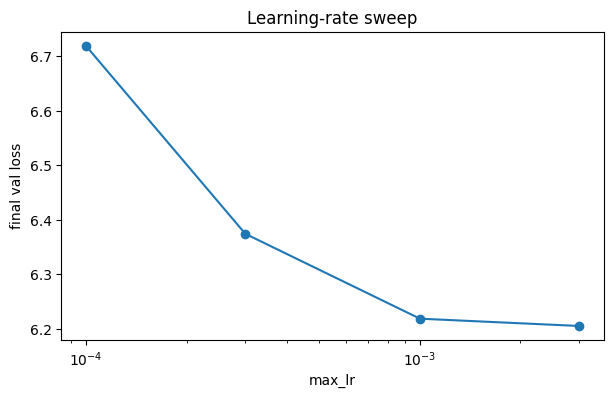

In [29]:
def run_lr_sweep(max_lrs: list[float], *, steps: int = 150) -> dict[float, float]:
    results: dict[float, float] = {}
    for lr in max_lrs:
        torch.manual_seed(1)
        sweep_model = TransformerLM(vocab_size=vocab_size, **short_run_model_config)
        sweep_trainer = Trainer(
            sweep_model,
            max_steps=steps,
            max_lr=lr,
            min_lr=lr / 10,
            warmup_steps=max(1, steps // 10),
            eval_every=steps,
            log_every=steps,
            **lr_sweep_trainer_config,
            generator=torch.Generator().manual_seed(123),
        )
        sweep_history = sweep_trainer.train(train_ids, val_ids)
        results[lr] = sweep_history["val_loss"][-1]
        print(f"max_lr={lr:g} val_loss={results[lr]:.3f} perplexity={math.exp(results[lr]):.1f}")
    return results


lr_results = run_lr_sweep(lr_sweep_lrs, steps=lr_sweep_steps)

plt.figure(figsize=(7, 4))
plt.plot(list(lr_results.keys()), list(lr_results.values()), marker="o")
plt.xscale("log")
plt.xlabel("max_lr")
plt.ylabel("final val loss")
plt.title("Learning-rate sweep")
plt.show()

In [30]:
"Question: Which max_lr was best in this short sweep?"
"Answer: "
"Question: Which side of the U-shape is underfitting, and which side is instability?"
"Answer: "

'Answer: '

## Exercise 6 - Warmup and Clipping Ablations

Run short matched experiments with one safety feature removed. The goal is not a definitive benchmark; it is to see the failure signature in the curves.

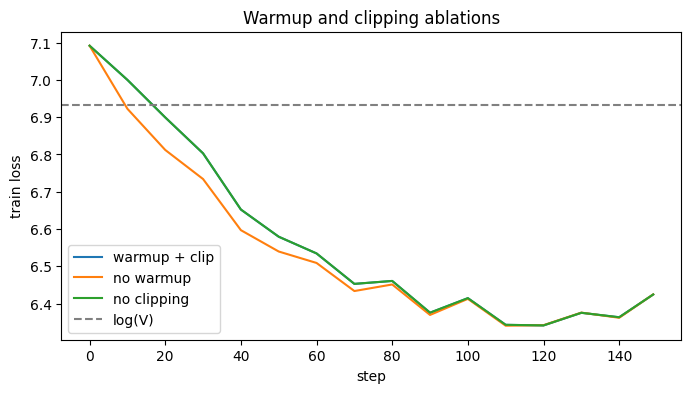

In [31]:
def run_ablation(name: str, *, warmup_steps: int, grad_clip: float | None, steps: int = 150) -> dict[str, list]:
    torch.manual_seed(2)
    ablation_model = TransformerLM(vocab_size=vocab_size, **short_run_model_config)
    ablation_trainer = Trainer(
        ablation_model,
        max_steps=steps,
        max_lr=ablation_max_lr,
        min_lr=ablation_min_lr,
        warmup_steps=warmup_steps,
        grad_clip=grad_clip,
        eval_every=steps,
        log_every=ablation_log_every,
        **ablation_trainer_config,
        generator=torch.Generator().manual_seed(321),
    )
    out = ablation_trainer.train(train_ids, val_ids)
    out["name"] = name
    return out


ablations = [
    run_ablation(**case, steps=ablation_steps)
    for case in ablation_cases
]

plt.figure(figsize=(8, 4))
for item in ablations:
    plt.plot(item["step"], item["train_loss"], label=item["name"])
plt.axhline(math.log(vocab_size), color="gray", linestyle="--", label="log(V)")
plt.xlabel("step")
plt.ylabel("train loss")
plt.title("Warmup and clipping ablations")
plt.legend()
plt.show()

In [32]:
"Question: Which ablation changed the first 50 steps the most?"
"Answer: "
"Question: Did no-clipping show larger gradient norm spikes, or was this tiny run too small to expose them?"
"Answer: "

'Answer: '